In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
df.describe().T     

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

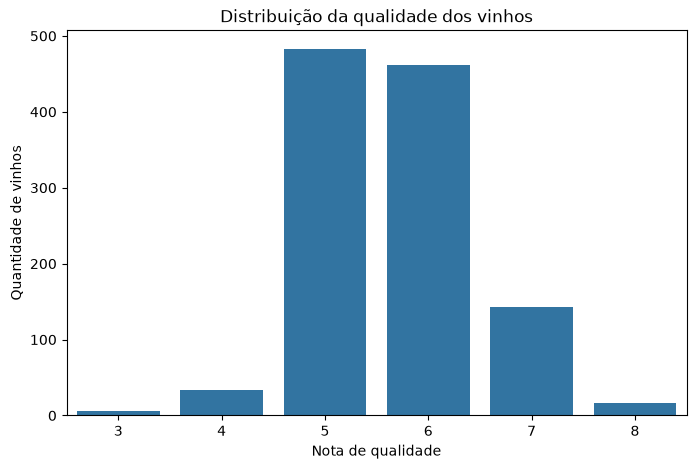

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribuição da qualidade dos vinhos")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de vinhos")

plt.show()

In [10]:
df["quality_class"] = (df["quality"] >= 7).astype(int)

In [11]:
df["quality_class"].value_counts()

quality_class
0    984
1    159
Name: count, dtype: int64

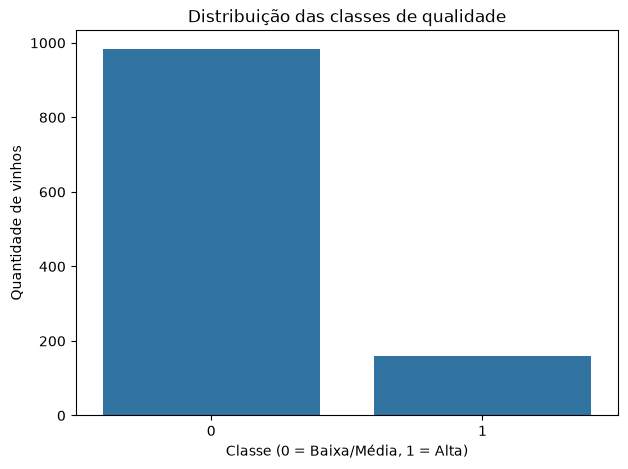

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="quality_class")

plt.title("Distribuição das classes de qualidade")
plt.xlabel("Classe (0 = Baixa/Média, 1 = Alta)")
plt.ylabel("Quantidade de vinhos")

plt.show()

In [13]:
df["quality_class"].value_counts(normalize=True) * 100

quality_class
0    86.089239
1    13.910761
Name: proportion, dtype: float64

In [15]:
class_distribution = (
    df["quality_class"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("Classe")
    .reset_index(name="Percentual")
)

class_distribution

,Classe,Percentual
0,0,86.089239
1,1,13.910761


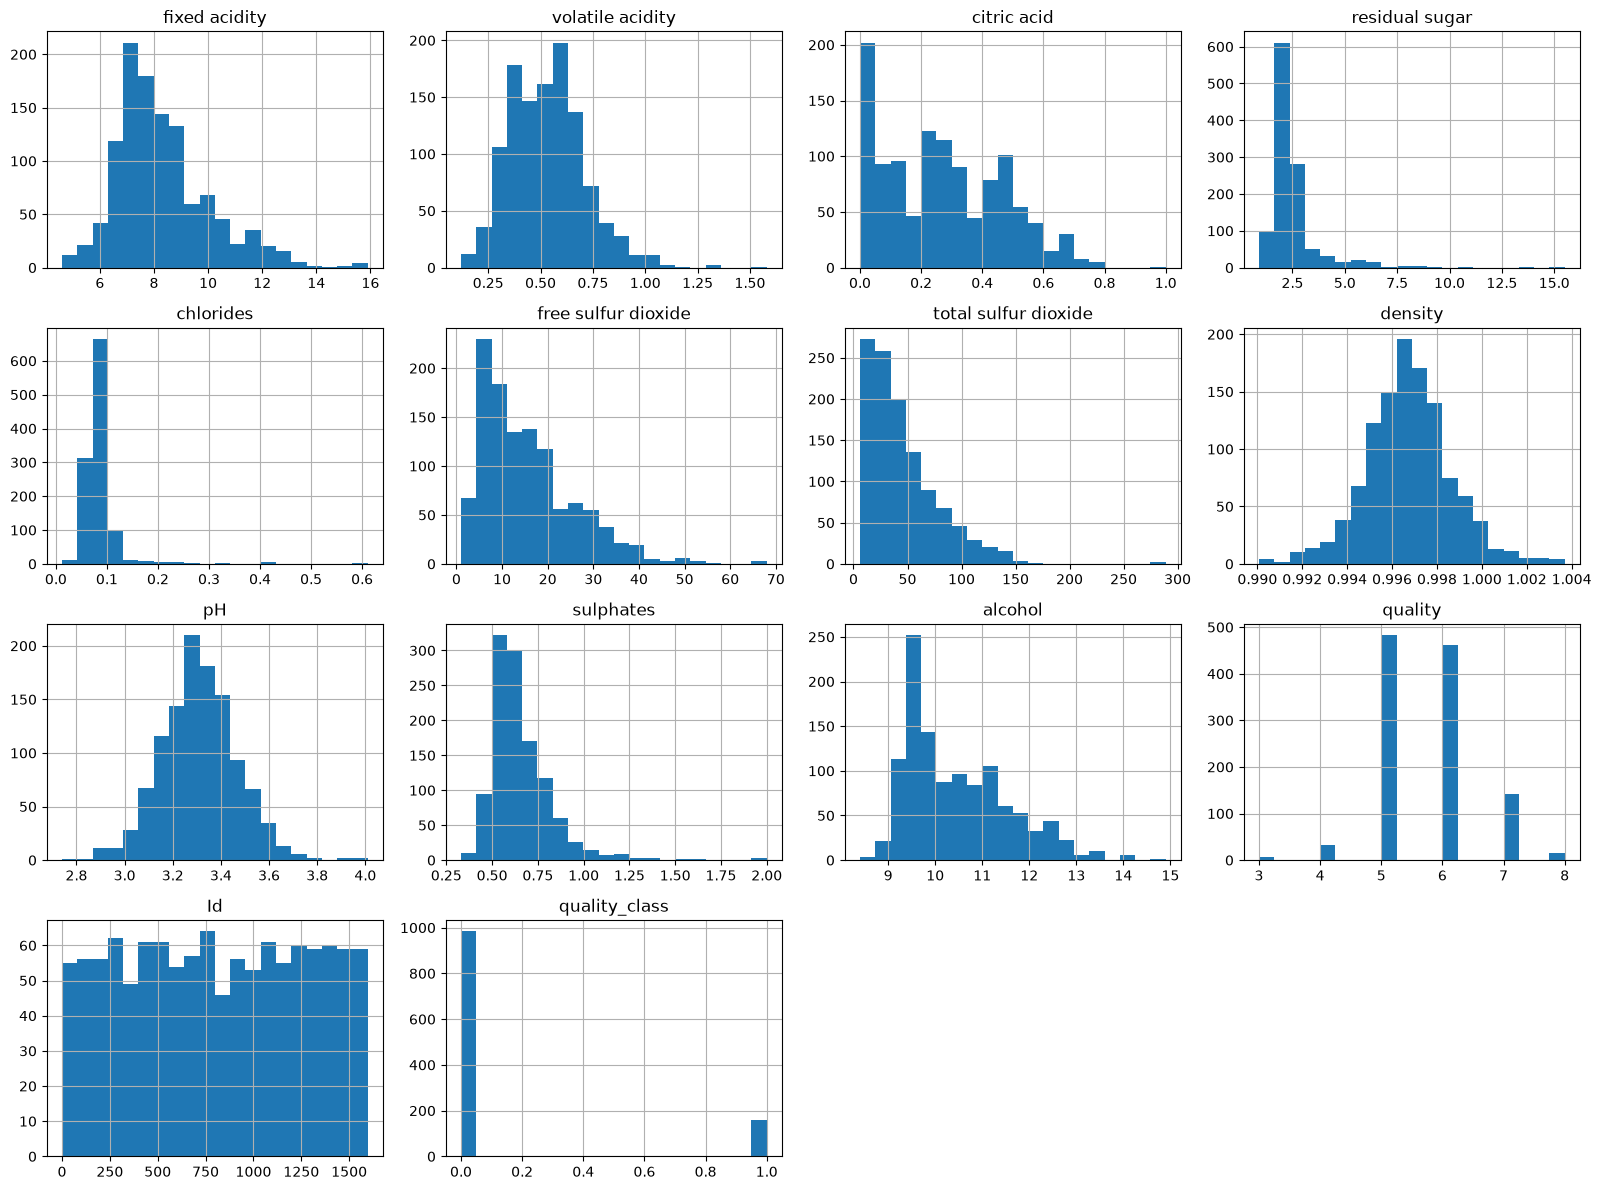

In [16]:
df.hist(
    figsize=(16, 12),
    bins=20
)

plt.tight_layout()
plt.show()

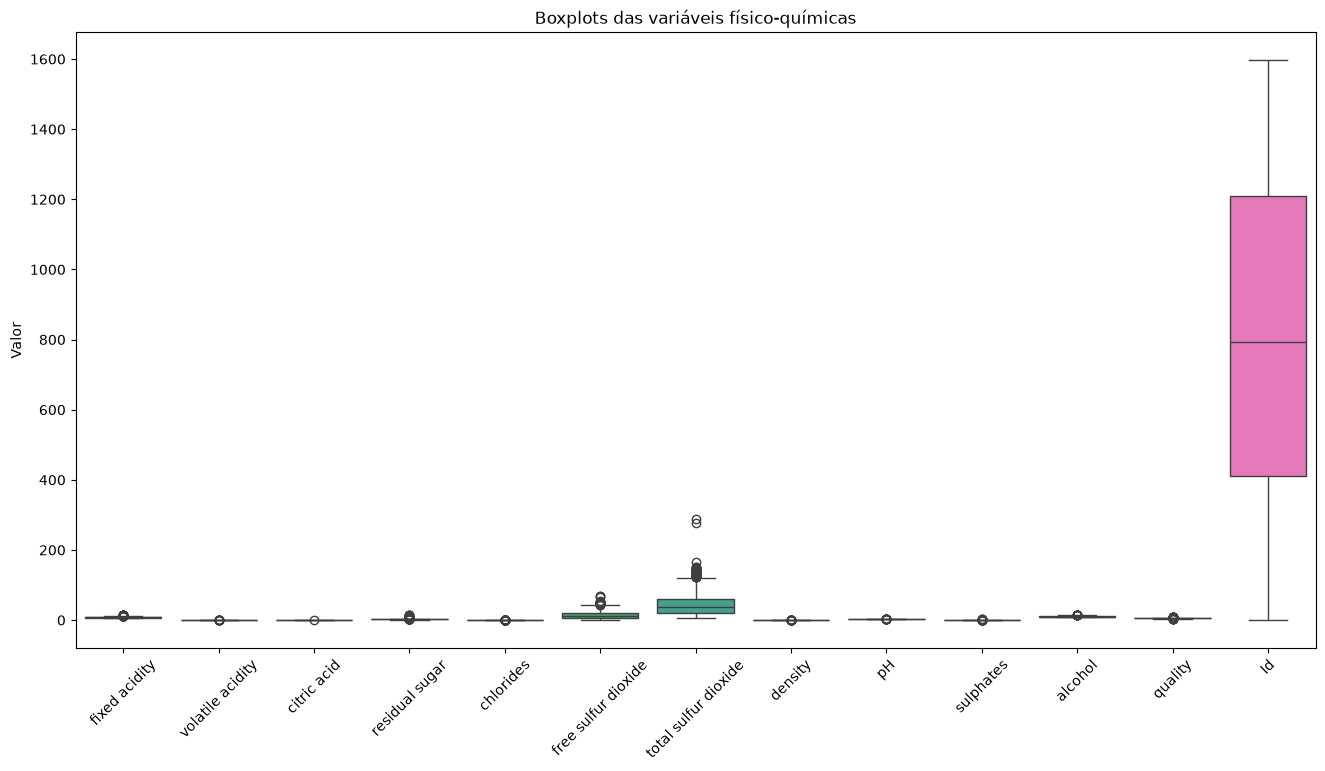

In [17]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df.drop(columns=["quality_class"]))

plt.xticks(rotation=45)
plt.title("Boxplots das variáveis físico-químicas")
plt.ylabel("Valor")

plt.show()

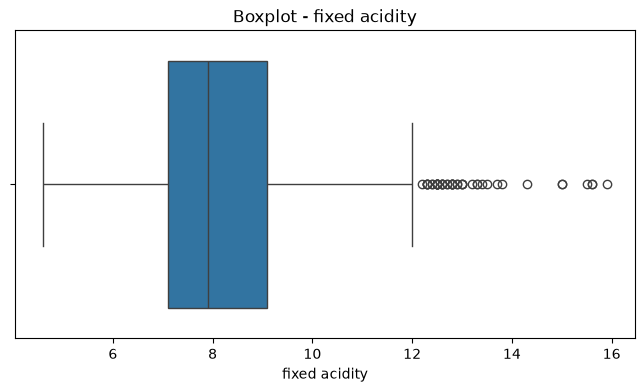

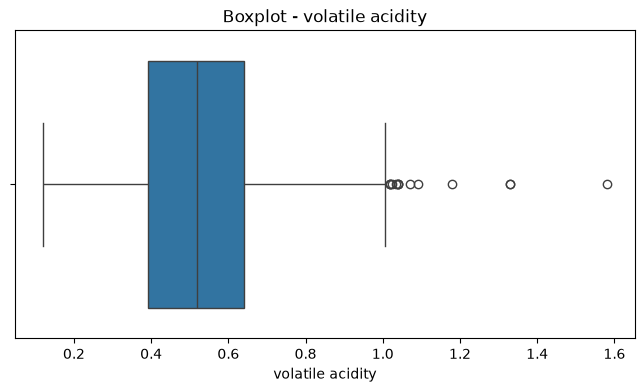

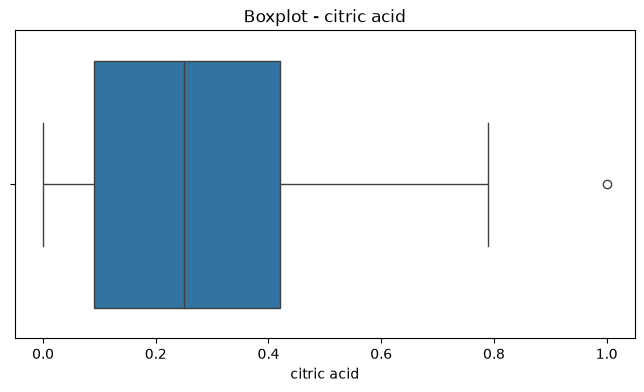

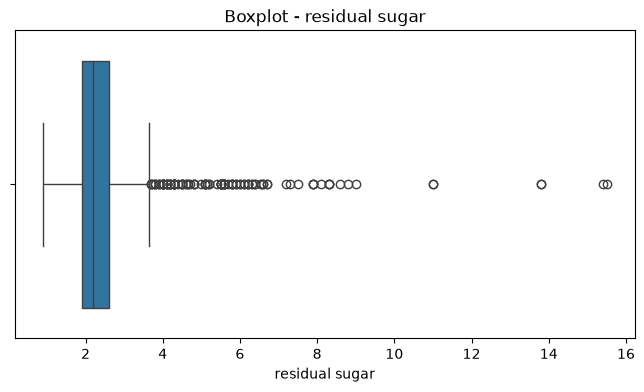

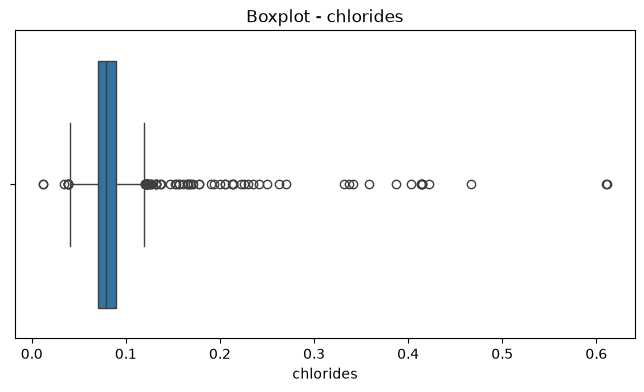

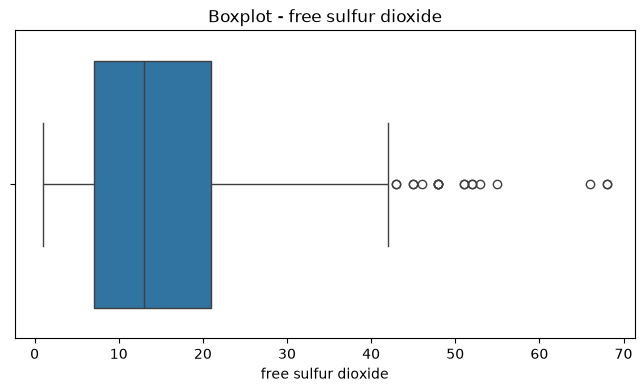

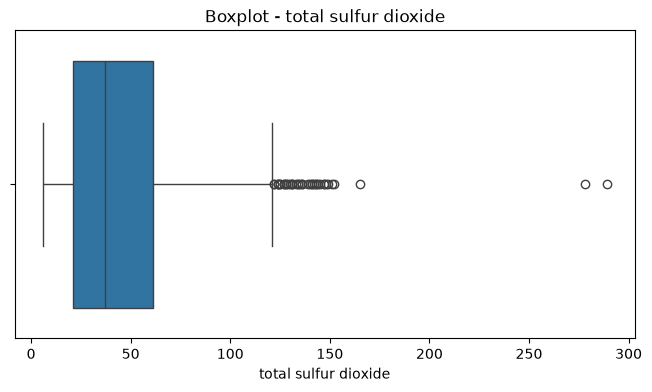

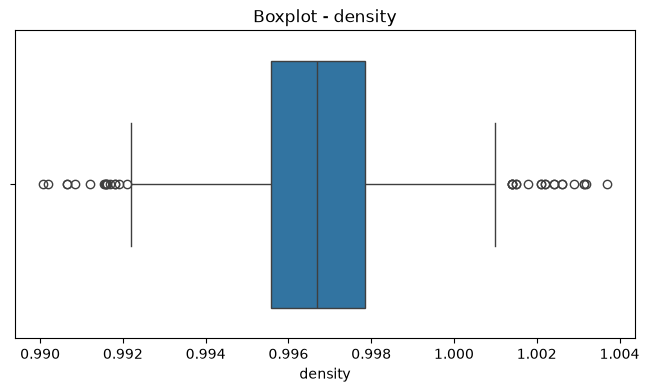

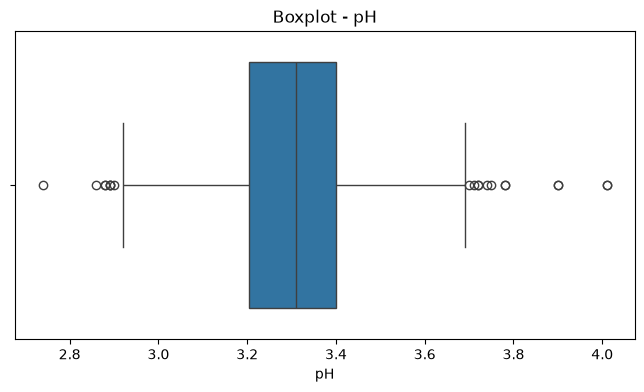

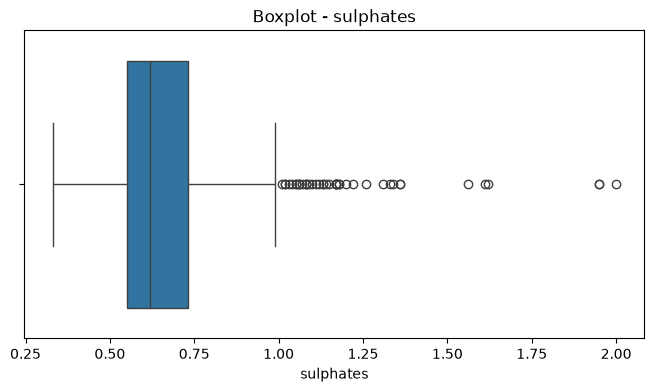

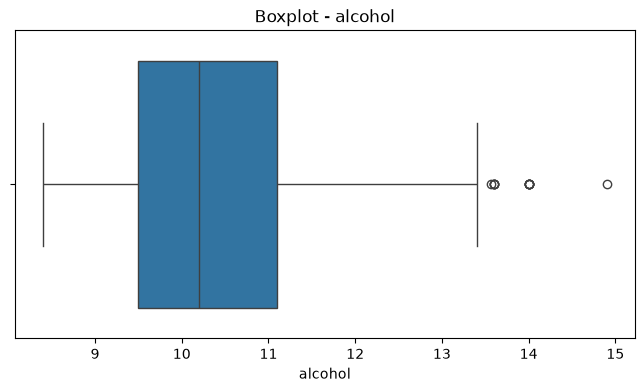

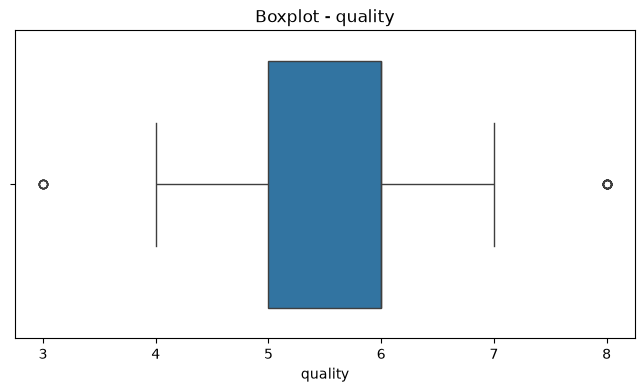

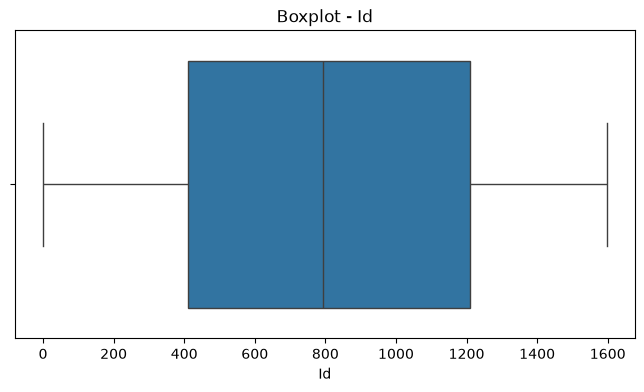

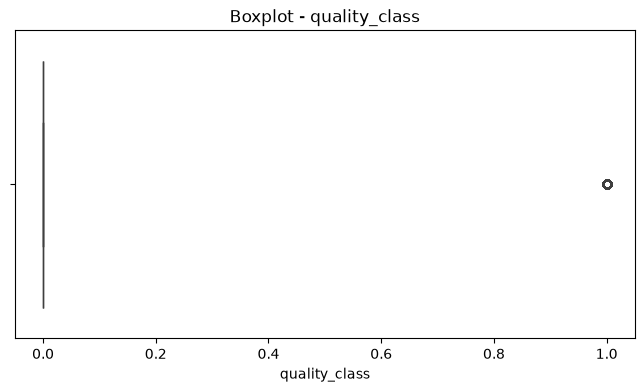

In [18]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Boxplot - {column}")
    plt.xlabel(column)
    
    plt.show()

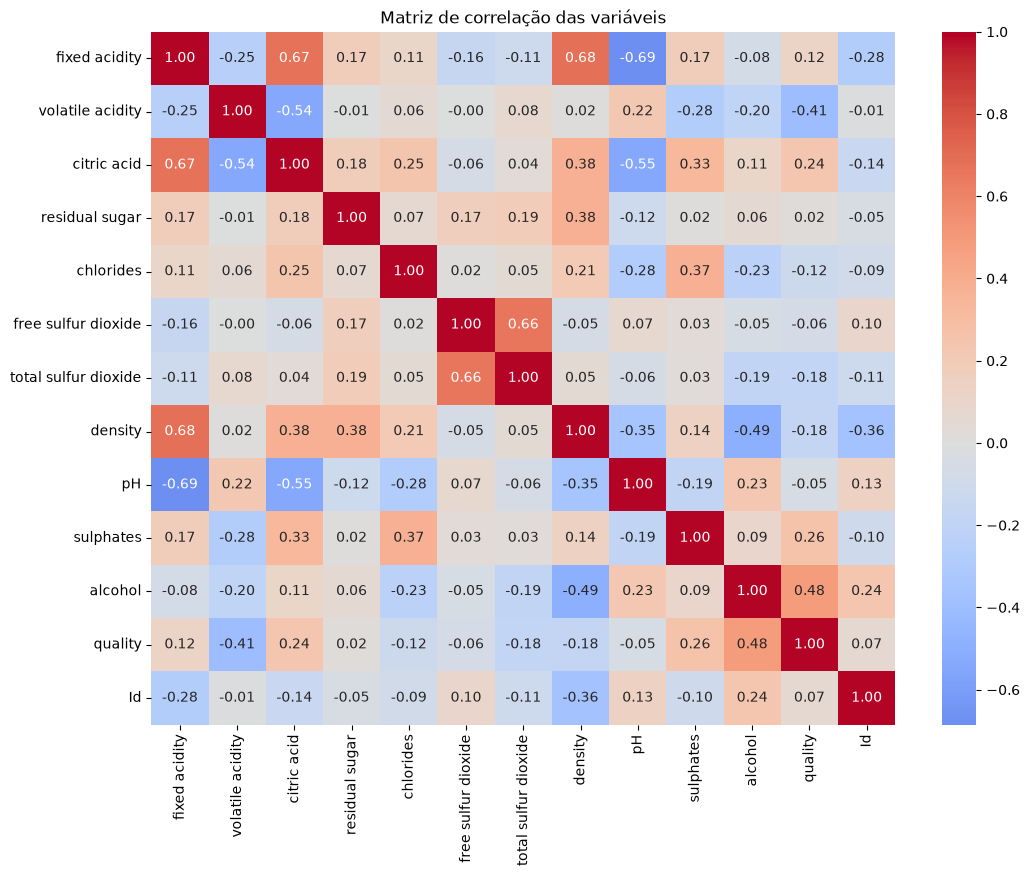

In [19]:
correlation = df.drop(columns=["quality_class"]).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlação das variáveis")

plt.show()

In [20]:
correlation["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

In [21]:
quality_correlation = (
    df.drop(columns=["quality_class"])
    .corr()["quality"]
    .sort_values(ascending=False)
)

quality_correlation

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

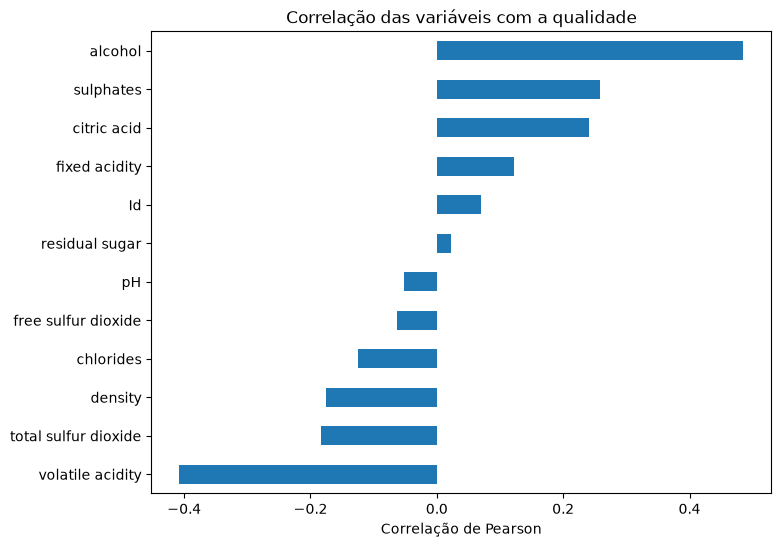

In [22]:
plt.figure(figsize=(8, 6))

quality_correlation.drop("quality").sort_values().plot(
    kind="barh"
)

plt.title("Correlação das variáveis com a qualidade")
plt.xlabel("Correlação de Pearson")

plt.show()

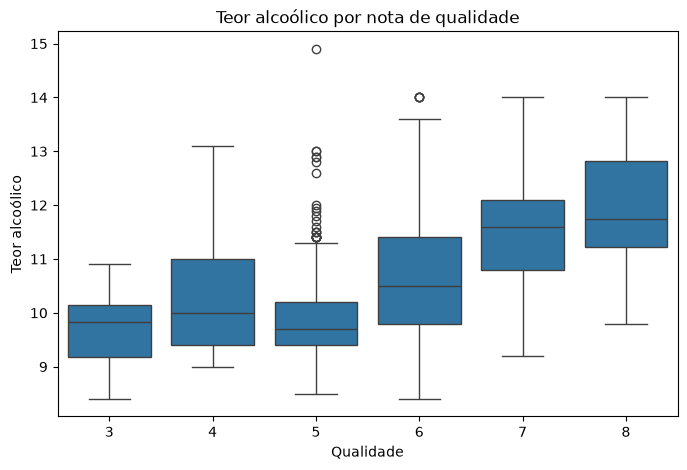

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)

plt.title("Teor alcoólico por nota de qualidade")
plt.xlabel("Qualidade")
plt.ylabel("Teor alcoólico")

plt.show()

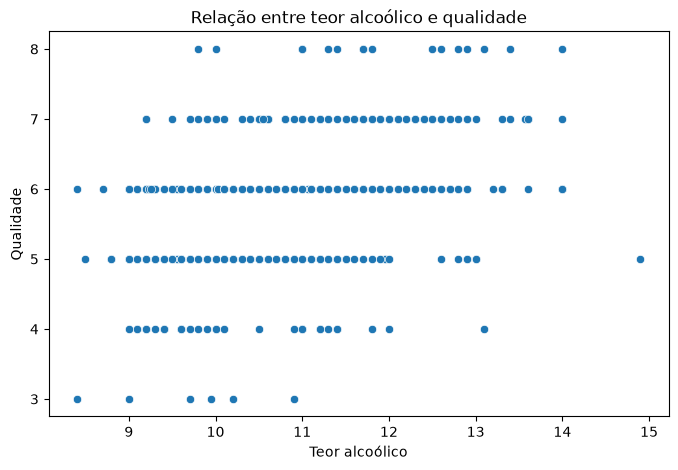

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="quality"
)

plt.title("Relação entre teor alcoólico e qualidade")
plt.xlabel("Teor alcoólico")
plt.ylabel("Qualidade")

plt.show()

In [35]:
df = df.drop(columns=["Id"], errors="ignore")

In [42]:
import numpy as np
from pathlib import Path
from scipy import stats

# Remove colunas que não são características do vinho
df = df.drop(columns=["Id", "high_quality"], errors="ignore")

FEATURES = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
    "density", "ph", "sulphates", "alcohol",
]

RESULTS = Path("../results")
RESULTS.mkdir(parents=True, exist_ok=True)

In [43]:
corr_features = df[FEATURES].corr(method="spearman")

pares = (
    corr_features
    .where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
    .stack()
    .rename("correlacao")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
pares["abs"] = pares["correlacao"].abs()

pares.sort_values("abs", ascending=False).head(10).round(3)

,feature_a,feature_b,correlacao,abs
61,free_sulfur_dioxide,total_sulfur_dioxide,0.794,0.794
8,fixed_acidity,ph,-0.707,0.707
2,fixed_acidity,citric_acid,0.654,0.654
7,fixed_acidity,density,0.630,0.630
13,volatile_acidity,citric_acid,-0.601,0.601
30,citric_acid,ph,-0.545,0.545
87,density,alcohol,-0.471,0.471
51,chlorides,density,0.427,0.427
40,residual_sugar,density,0.423,0.423
29,citric_acid,density,0.355,0.355


In [44]:
corr_pearson = df[FEATURES].corr()
vif = pd.Series(np.diag(np.linalg.inv(corr_pearson.values)), index=FEATURES, name="VIF")
vif.sort_values(ascending=False).round(2)

fixed_acidity           7.78
density                 6.60
ph                      3.39
citric_acid             3.22
alcohol                 3.18
total_sulfur_dioxide    2.10
free_sulfur_dioxide     1.91
volatile_acidity        1.78
residual_sugar          1.74
chlorides               1.54
sulphates               1.44
Name: VIF, dtype: float64

### Correlação entre features

As correlações mais fortes seguem relações químicas esperadas:

- **SO₂ livre × SO₂ total (0,79):** o livre é parte do total.
- **Acidez fixa × pH (-0,71):** quanto mais ácido, menor o pH.
- **Acidez fixa × ácido cítrico (0,65):** o cítrico compõe a acidez fixa.
- **Acidez fixa × densidade (0,63):** ácidos dissolvidos aumentam a densidade.
- **Acidez volátil × ácido cítrico (-0,60):** vinhos com mais cítrico tendem a ter menos acidez volátil.
- **Densidade × álcool (-0,47):** o álcool é menos denso que a água.

O VIF indicou colinearidade moderada em acidez fixa (7,78) e densidade (6,60),
sem chegar a 10. Isso é relevante para modelos lineares; árvores toleram melhor.

In [46]:
rows = []
for f in FEATURES:
    r_p, p_p = stats.pearsonr(df[f], df["quality"])
    r_s, p_s = stats.spearmanr(df[f], df["quality"])
    rows.append({"feature": f, "pearson": r_p, "spearman": r_s, "p_spearman": p_s})

corr_quality = (
    pd.DataFrame(rows)
    .set_index("feature")
    .sort_values("spearman", key=abs, ascending=False)
)
corr_quality.round(4)

,pearson,spearman,p_spearman
feature,,,
alcohol,0.4849,0.4954,0.0000
volatile_acidity,-0.4074,-0.3978,0.0000
sulphates,0.2577,0.3937,0.0000
citric_acid,0.2408,0.2229,0.0000
total_sulfur_dioxide,-0.1833,-0.1946,0.0000
chlorides,-0.1241,-0.1938,0.0000
density,-0.1752,-0.1765,0.0000
fixed_acidity,0.1220,0.1039,0.0004
free_sulfur_dioxide,-0.0633,-0.0592,0.0453


### Relação das features com a qualidade

- **Álcool** (ρ ≈ 0,50) é a variável mais associada a notas maiores.
- **Acidez volátil** (ρ ≈ -0,40) é a principal associada a notas menores.
- **Sulfatos** (ρ ≈ 0,39) e **ácido cítrico** (ρ ≈ 0,23) têm relação positiva moderada.
- **SO₂ total, cloretos e densidade** têm relação negativa fraca (≈ -0,18 a -0,19).
- **pH e açúcar residual** não têm relação significativa (p > 0,05).
- Em sulfatos e cloretos, o Spearman supera o Pearson, o que sugere influência de outliers.

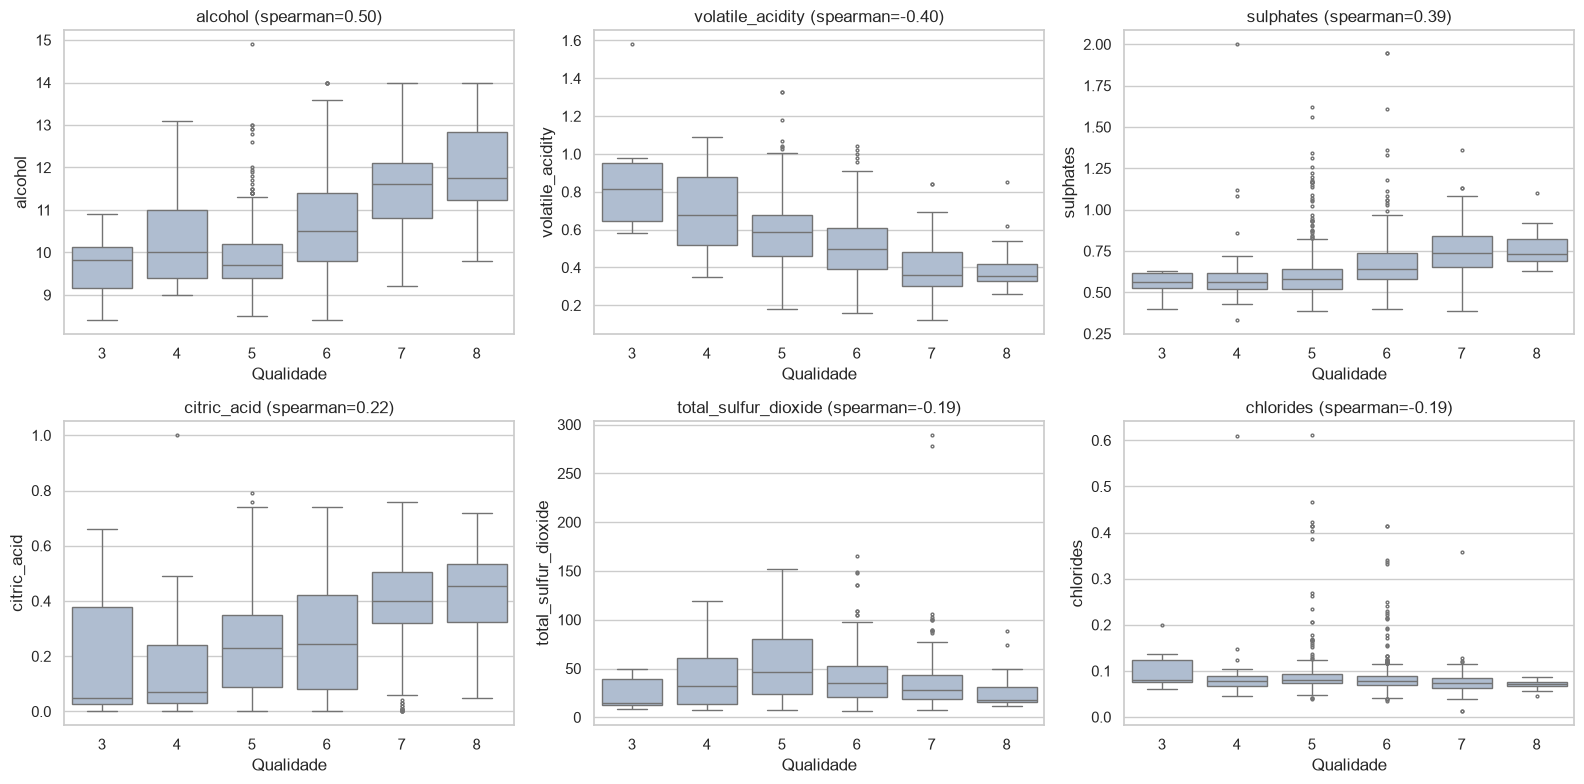

In [47]:
top6 = corr_quality.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes.ravel(), top6):
    sns.boxplot(data=df, x="quality", y=f, ax=ax, color="#a9bcd6", fliersize=2)
    ax.set_title(f"{f} (spearman={corr_quality.loc[f, 'spearman']:.2f})")
    ax.set_xlabel("Qualidade")
plt.tight_layout()
plt.savefig(RESULTS / "07_boxplot_top6_por_nota.png", dpi=150)
plt.show()

### Comportamento das variáveis por nota

- **Álcool** e **acidez volátil** mostram tendência clara e contínua: mais álcool e menos acidez volátil acompanham notas maiores.
- **Sulfatos** e **ácido cítrico** crescem com a nota, mas de forma mais fraca, com sobreposição grande entre as notas.
- **SO₂ total** não é monotônico: sobe até a nota 5 e depois cai, então a correlação linear resume mal a relação.
- **Cloretos** têm medianas quase iguais em todas as notas; a correlação vem de outliers, principalmente nas notas 5 e 6.
- As notas 3 e 8 têm poucos vinhos, então as conclusões sobre os extremos devem ser cautelosas.

In [50]:
alta = df[df["quality_class"] == 1]
baixa = df[df["quality_class"] == 0]

rows = []
for f in FEATURES:
    u, p = stats.mannwhitneyu(alta[f], baixa[f], alternative="two-sided")
    auc = u / (len(alta) * len(baixa))
    sd = np.sqrt(((len(alta) - 1) * alta[f].var() + (len(baixa) - 1) * baixa[f].var())
                 / (len(alta) + len(baixa) - 2))
    rows.append({
        "feature": f,
        "mediana_baixa": baixa[f].median(),
        "mediana_alta": alta[f].median(),
        "media_baixa": baixa[f].mean(),
        "media_alta": alta[f].mean(),
        "cohen_d": (alta[f].mean() - baixa[f].mean()) / sd,
        "AUC": auc,
        "p_valor": p,
    })

comparacao = (
    pd.DataFrame(rows)
    .set_index("feature")
    .sort_values("cohen_d", key=abs, ascending=False)
)
comparacao.round(4)

,mediana_baixa,mediana_alta,media_baixa,media_alta,cohen_d,AUC,p_valor
feature,,,,,,,
alcohol,10.0000,11.6000,10.2666,11.5284,1.2739,0.8191,0.0000
volatile_acidity,0.5500,0.3600,0.5533,0.3953,-0.9230,0.2281,0.0000
citric_acid,0.2400,0.4100,0.2485,0.3912,0.7491,0.7048,0.0000
sulphates,0.6000,0.7400,0.6435,0.7458,0.6140,0.7427,0.0000
density,0.9968,0.9957,0.9968,0.9960,-0.4341,0.3722,0.0000
fixed_acidity,7.8000,8.7000,8.2246,8.8465,0.3585,0.6022,0.0000
total_sulfur_dioxide,39.0000,28.0000,47.4080,36.6730,-0.3294,0.3786,0.0000
chlorides,0.0800,0.0730,0.0889,0.0747,-0.3019,0.3530,0.0000
ph,3.3150,3.2700,3.3156,3.2825,-0.2123,0.4328,0.0065


In [49]:
df = df.drop(columns=["Id"], errors="ignore")
df["quality_class"] = (df["quality"] >= 7).astype(int)

print(df.columns.tolist())
print(df["quality_class"].value_counts())

['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality', 'quality_class']
quality_class
0    984
1    159
Name: count, dtype: int64


### Comparação das features entre classes

Comparando vinhos de alta qualidade (nota ≥ 7) com os de baixa/média (nota < 7):

- **Álcool** é a variável que mais separa as classes (d = 1,27; AUC = 0,82): mediana de 11,6 na classe alta contra 10,0 na baixa/média.
- **Acidez volátil** tem efeito grande no sentido oposto (d = -0,92): 0,36 na classe alta contra 0,55.
- **Ácido cítrico** (d = 0,75) e **sulfatos** (d = 0,61) têm efeito médio e são maiores nos vinhos de alta qualidade.
- **Densidade, acidez fixa, SO₂ total e cloretos** têm diferenças pequenas (|d| entre 0,30 e 0,43).
- **pH, açúcar residual e SO₂ livre** têm efeito desprezível e não se sustentam após correção para múltiplos testes.

As variáveis que mais diferenciam as classes coincidem com as mais correlacionadas com a nota.

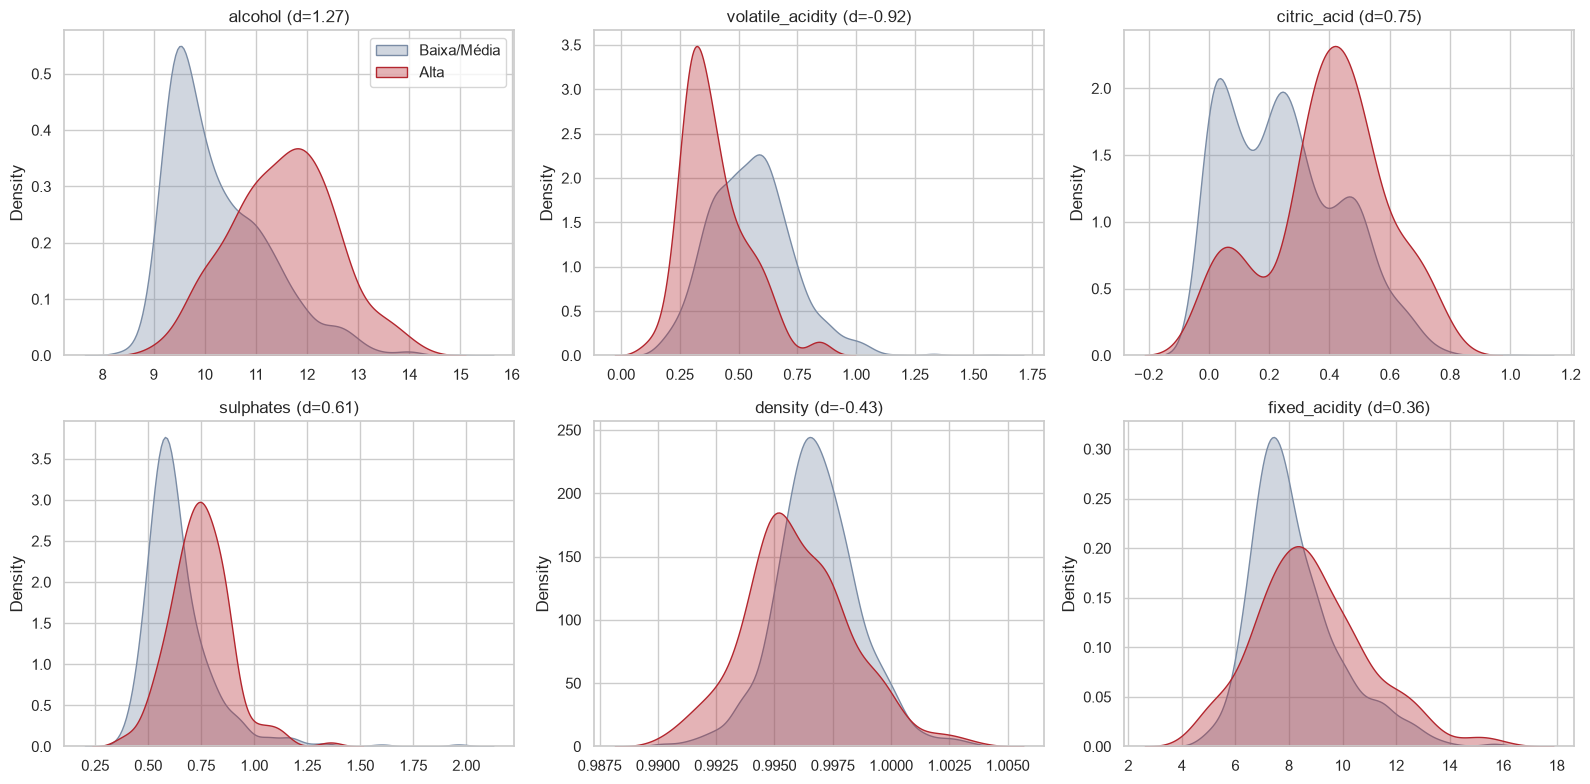

In [51]:
top6_classes = comparacao.index[:6]
cores = {0: "#7a8ca5", 1: "#b3262e"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes.ravel(), top6_classes):
    for classe, nome in [(0, "Baixa/Média"), (1, "Alta")]:
        sns.kdeplot(df.loc[df["quality_class"] == classe, f], ax=ax, fill=True,
                    alpha=0.35, color=cores[classe], label=nome, common_norm=False)
    ax.set_title(f"{f} (d={comparacao.loc[f, 'cohen_d']:.2f})")
    ax.set_xlabel("")
axes[0, 0].legend()
plt.tight_layout()
plt.savefig(RESULTS / "08_densidade_por_classe.png", dpi=150)
plt.show()

### Distribuições por classe

- **Álcool:** os vinhos de alta qualidade se concentram em teores maiores (pico perto de 11,8%) e quase não aparecem abaixo de 10%. Há sobreposição entre 10% e 12%.
- **Acidez volátil:** a classe alta se concentra em valores baixos (perto de 0,3); valores altos são típicos da classe baixa/média.
- **Ácido cítrico:** a classe baixa/média tem muitos vinhos com valor próximo de zero; a alta tem pico em torno de 0,4.
- **Sulfatos:** a classe alta está deslocada para valores maiores, mas as duas classes têm cauda longa de valores extremos.
- **Densidade e acidez fixa** têm distribuições muito sobrepostas e separam pouco as classes isoladamente.
- O trecho negativo da curva do ácido cítrico é um efeito de suavização do gráfico, não um valor real.

In [54]:
rows = []
mascara_outliers = pd.DataFrame(False, index=df.index, columns=FEATURES)

for f in FEATURES:
    q1, q3 = df[f].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    m = (df[f] < lim_inf) | (df[f] > lim_sup)
    mascara_outliers[f] = m
    rows.append({
        "feature": f,
        "n_outliers": int(m.sum()),
        "%_da_base": m.mean() * 100,
        "%_alta_nos_outliers": df.loc[m, "quality_class"].mean() * 100 if m.any() else np.nan,
        "valor_max": df[f].max(),
    })

outliers_resumo = (
    pd.DataFrame(rows)
    .set_index("feature")
    .sort_values("n_outliers", ascending=False)
)

print(f"Taxa base de vinhos de alta qualidade: {df['quality_class'].mean() * 100:.1f}%")
outliers_resumo.round(2)

Taxa base de vinhos de alta qualidade: 13.9%


,n_outliers,%_da_base,%_alta_nos_outliers,valor_max
feature,,,,
residual_sugar,110,9.62,22.73,15.50
chlorides,77,6.74,9.09,0.61
fixed_acidity,44,3.85,25.00,15.90
sulphates,43,3.76,18.60,2.00
total_sulfur_dioxide,40,3.50,5.00,289.00
density,36,3.15,30.56,1.00
ph,20,1.75,20.00,4.01
free_sulfur_dioxide,18,1.57,11.11,68.00
volatile_acidity,14,1.22,0.00,1.58


In [56]:
rows = []
taxa_base = df["quality_class"].mean()

for f in FEATURES:
    m = mascara_outliers[f]
    if m.sum() < 5:
        continue  # poucos casos para testar (ácido cítrico tem só 1)
    alta_out = int((m & (df["quality_class"] == 1)).sum())
    baixa_out = int((m & (df["quality_class"] == 0)).sum())
    alta_in = int((~m & (df["quality_class"] == 1)).sum())
    baixa_in = int((~m & (df["quality_class"] == 0)).sum())
    _, p = stats.fisher_exact([[alta_out, baixa_out], [alta_in, baixa_in]])
    rows.append({
        "feature": f,
        "n_outliers": int(m.sum()),
        "alta_nos_outliers": alta_out,
        "esperado_ao_acaso": round(m.sum() * taxa_base, 1),
        "p_fisher": p,
    })

fisher = pd.DataFrame(rows).set_index("feature").sort_values("p_fisher")
fisher.round(4)

,n_outliers,alta_nos_outliers,esperado_ao_acaso,p_fisher
feature,,,,
alcohol,12,6,1.7,0.0030
residual_sugar,110,25,15.3,0.0084
density,36,11,5.0,0.0111
fixed_acidity,44,11,6.1,0.0426
total_sulfur_dioxide,40,2,5.6,0.1070
chlorides,77,7,10.7,0.2359
volatile_acidity,14,0,1.9,0.2388
sulphates,43,8,6.0,0.3676
ph,20,4,2.8,0.5081


### Relevância dos outliers

Comparei a proporção de vinhos de alta qualidade dentro dos outliers (IQR) com a do restante da base (teste exato de Fisher):

- **Álcool** é o único com resultado significativo após correção para múltiplos testes (p = 0,003): 6 dos 12 outliers são de alta qualidade, contra 1,7 esperado ao acaso.
- **Açúcar residual, densidade e acidez fixa** têm mais vinhos de alta qualidade que o esperado, mas sem significância após a correção; tratados como indícios.
- **Acidez volátil:** nenhum dos 14 outliers é de alta qualidade, mas o número de casos é pequeno para confirmar.
- Nas demais variáveis, os outliers não se associam à qualidade.

Decisão: investigar com mais detalhe álcool, açúcar residual, densidade e acidez fixa.

In [57]:
relevantes = ["alcohol", "residual_sugar", "density", "fixed_acidity"]

rows = []
for f in relevantes:
    q1, q3 = df[f].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    m = mascara_outliers[f]
    winsor = df[f].clip(lim_inf, lim_sup)
    rows.append({
        "feature": f,
        "outliers_acima": int((df[f] > lim_sup).sum()),
        "outliers_abaixo": int((df[f] < lim_inf).sum()),
        "nota_media_outliers": df.loc[m, "quality"].mean(),
        "nota_media_demais": df.loc[~m, "quality"].mean(),
        "pearson_original": stats.pearsonr(df[f], df["quality"])[0],
        "pearson_winsorizado": stats.pearsonr(winsor, df["quality"])[0],
    })

investigacao = pd.DataFrame(rows).set_index("feature")
investigacao.round(3)

,outliers_acima,outliers_abaixo,nota_media_outliers,nota_media_demais,pearson_original,pearson_winsorizado
feature,,,,,,
alcohol,12,0,6.500,5.648,0.485,0.489
residual_sugar,110,0,5.727,5.650,0.022,0.034
density,20,16,6.111,5.642,-0.175,-0.177
fixed_acidity,44,0,5.886,5.648,0.122,0.122


### Investigação dos outliers relevantes

- Os outliers de **álcool** estão todos acima da faixa normal e têm nota média maior (6,5 contra 5,65). Parecem vinhos legítimos de teor alcoólico alto, não erros.
- Em **açúcar residual, acidez fixa e densidade**, a nota média dos outliers é próxima à dos demais vinhos.
- Limitar os valores extremos (winsorizing) quase não altera a correlação com a qualidade em nenhuma das quatro variáveis, então os outliers não distorcem as relações.
- Decisão: **manter os outliers**. Para modelos sensíveis a escala, usar RobustScaler ou transformação logarítmica; modelos de árvore não exigem tratamento.

In [58]:
extremos = []
for f in relevantes:
    z = stats.zscore(df[f])
    for i in np.argsort(-np.abs(z))[:3]:
        extremos.append({
            "feature": f,
            "indice": df.index[i],
            "valor": df[f].iloc[i],
            "z": z[i],
            "quality": df["quality"].iloc[i],
        })

pd.DataFrame(extremos).round(3)

,feature,indice,valor,z,quality
0,alcohol,462,14.900,4.121,5
1,alcohol,98,14.000,3.289,6
2,alcohol,329,14.000,3.289,6
3,residual_sugar,339,15.500,9.568,5
4,residual_sugar,1022,15.400,9.494,6
5,residual_sugar,1051,13.800,8.314,5
6,density,1022,1.004,3.617,6
7,density,714,0.990,-3.461,6
8,density,787,0.990,-3.394,6
9,fixed_acidity,462,15.900,4.344,5


### Registros mais extremos

Os 3 vinhos mais extremos de cada variável relevante foram inspecionados:

- Nenhum valor é fisicamente impossível (álcool máximo de 14,9%, densidade máxima de 1,004).
- O vinho 1022 combina açúcar residual alto (15,4) e densidade alta (1,004), o que é coerente: o açúcar dissolvido aumenta a densidade.
- O vinho 462 é extremo em duas variáveis (álcool 14,9% e acidez fixa 15,9) e tem nota 5, um perfil raro que foge da tendência geral.
- As notas dos registros extremos ficam entre 5 e 7.

Conclusão: os outliers parecem perfis reais de vinho, não erros de medição, e serão mantidos.

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X = df[FEATURES]
y = df["quality_class"]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

info_mutua = pd.Series(
    mutual_info_classif(X, y, random_state=42), index=FEATURES, name="info_mutua"
)

rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", min_samples_leaf=3,
    random_state=42, n_jobs=1
).fit(X_tr, y_tr)

perm = permutation_importance(
    rf, X_te, y_te, scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=1
)
perm_rf = pd.Series(perm.importances_mean, index=FEATURES, name="perm_rf_auc")

importancia = pd.concat([
    info_mutua,
    perm_rf,
    corr_quality["spearman"].abs().rename("abs_spearman"),
    (comparacao["AUC"] - 0.5).abs().rename("abs_auc"),
], axis=1)
importancia["rank_medio"] = importancia.rank(ascending=False).mean(axis=1)

importancia.sort_values("rank_medio").round(4)

,info_mutua,perm_rf_auc,abs_spearman,abs_auc,rank_medio
alcohol,0.1056,0.0815,0.4954,0.3191,1.00
volatile_acidity,0.0706,0.0264,0.3978,0.2719,2.50
sulphates,0.0726,0.0336,0.3937,0.2427,2.50
citric_acid,0.0513,0.0196,0.2229,0.2048,4.50
total_sulfur_dioxide,0.0551,0.0208,0.1946,0.1214,5.00
chlorides,0.0302,0.0131,0.1938,0.1470,6.75
density,0.0345,0.0157,0.1765,0.1278,6.75
fixed_acidity,0.0462,0.0021,0.1039,0.1022,8.00
ph,0.0376,0.0027,0.0332,0.0672,8.75
free_sulfur_dioxide,0.0030,0.0042,0.0592,0.0537,9.50


### Variáveis potencialmente mais importantes

Combinei quatro critérios: informação mútua, importância por permutação de um Random Forest, |correlação de Spearman| e AUC univariada.

- **Álcool** lidera nos quatro critérios, com ampla vantagem.
- **Acidez volátil** e **sulfatos** vêm em seguida (empatados), e depois **ácido cítrico**.
- **SO₂ total** sobe no ranking por métodos não lineares, de acordo com sua relação não monotônica com a nota.
- **Acidez fixa** tem informação própria baixa no Random Forest: boa parte dela já é explicada por pH, densidade e ácido cítrico (colinearidade).
- **Açúcar residual** e **SO₂ livre** têm a menor importância nos quatro critérios.

Ressalva: a amostra de teste é pequena (cerca de 40 vinhos de alta qualidade), então a ordem das posições 2 a 5 é indicativa, não definitiva.

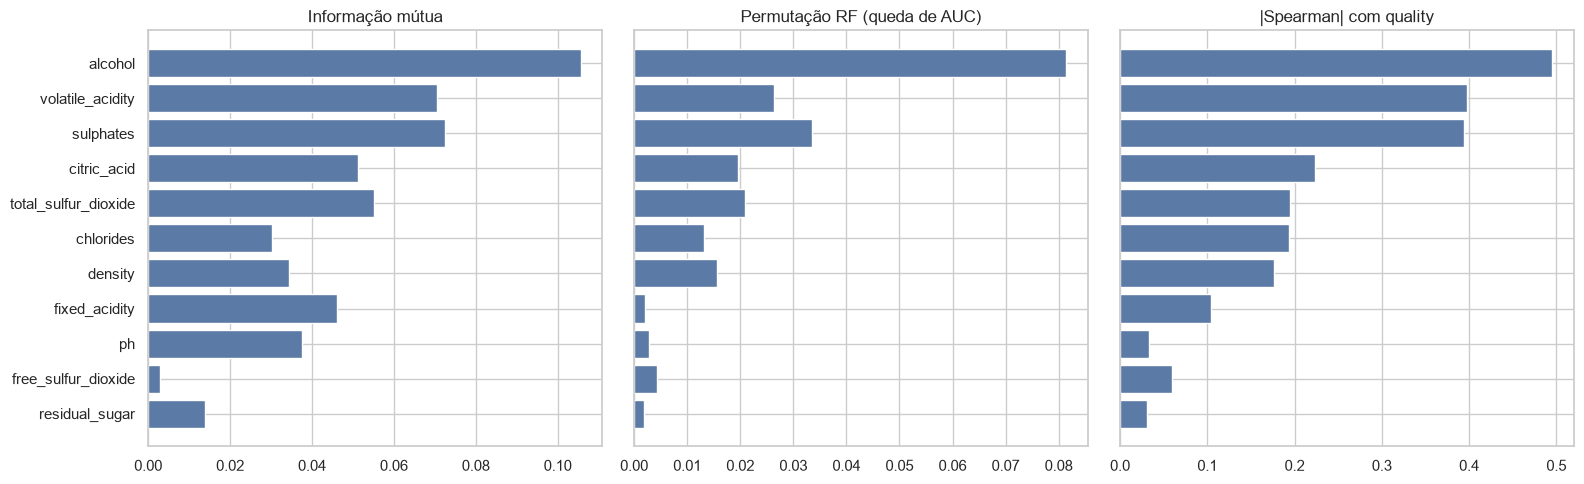

In [60]:
ordem = importancia.sort_values("rank_medio").index

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col, titulo in zip(
    axes,
    ["info_mutua", "perm_rf_auc", "abs_spearman"],
    ["Informação mútua", "Permutação RF (queda de AUC)", "|Spearman| com quality"],
):
    ax.barh(ordem[::-1], importancia.loc[ordem[::-1], col], color="#5b7aa5")
    ax.set_title(titulo)
plt.tight_layout()
plt.savefig(RESULTS / "12_importancia_variaveis.png", dpi=150)
plt.show()

## Hipóteses para a modelagem

**H1. Desbalanceamento.** Só 13,9% dos vinhos são de alta qualidade (razão de 6,2:1). A acurácia sozinha seria enganosa.
→ Usar divisão estratificada e `class_weight="balanced"`, e avaliar com recall, F1 e ROC-AUC da classe alta.

**H2. Poucas variáveis concentram o poder preditivo.** Álcool, acidez volátil, sulfatos e ácido cítrico lideram em todos os critérios.
→ Comparar o modelo completo com um modelo reduzido só com essas variáveis.

**H3. Existe efeito não linear.** O SO₂ total sobe de importância em métodos não lineares e tem relação não monotônica com a nota.
→ Esperar que modelos de árvore (Random Forest, Gradient Boosting) superem a regressão logística. Se isso acontecer, confirma a hipótese.

**H4. Multicolinearidade.** Acidez fixa (VIF 7,8) e densidade (VIF 6,6) são explicadas pelas outras variáveis.
→ Na regressão logística, testar sem essas duas ou usar regularização. Árvores toleram bem.

**H5. Outliers são informação, não ruído.** Os outliers de álcool estão ligados a notas maiores e nenhum valor é fisicamente impossível.
→ Manter os outliers. Usar RobustScaler ou transformação logarítmica nas variáveis assimétricas (como açúcar residual e cloretos) em modelos sensíveis à escala.

**H6. Variáveis candidatas a remoção.** Açúcar residual, SO₂ livre e pH têm importância próxima de zero em todos os critérios.
→ Testar se removê-las mantém o desempenho (modelo mais simples).

**H7. Feature engineering a testar.**
- Razão SO₂ livre / SO₂ total (parte do SO₂ que está ativa).
- Acidez total (fixa + volátil + cítrico) e razão acidez fixa / volátil.
- Interação álcool × sulfatos.

**H8. Cuidados de validação.**
- Padronizar só depois da divisão treino/teste (dentro de um Pipeline), para evitar vazamento.
- Verificar linhas duplicadas e removê-las antes da divisão.
- Usar validação cruzada estratificada, porque a classe alta tem só 159 vinhos.

In [61]:
df.duplicated().sum()

np.int64(125)

In [62]:
duplicadas = df.duplicated()
print("Duplicadas:", duplicadas.sum(), f"({duplicadas.mean():.1%})")
print("Classe alta entre as duplicadas:", f"{df.loc[duplicadas, 'quality_class'].mean():.1%}")

df_sem_dup = df.drop_duplicates()
print("Shape sem duplicadas:", df_sem_dup.shape)
print(df_sem_dup["quality_class"].value_counts())
print(f"% classe alta sem duplicadas: {df_sem_dup['quality_class'].mean():.1%}")

Duplicadas: 125 (10.9%)
Classe alta entre as duplicadas: 17.6%
Shape sem duplicadas: (1018, 13)
quality_class
0    881
1    137
Name: count, dtype: int64
% classe alta sem duplicadas: 13.5%


**H8. Cuidados de validação.**
- A base tem **125 linhas duplicadas (≈10,9%)**. Removê-las antes da divisão treino/teste, para que a mesma amostra não apareça nos dois conjuntos e infle as métricas.
- Padronizar só depois da divisão (dentro de um Pipeline), para evitar vazamento.
- Usar validação cruzada estratificada, porque a classe alta tem poucos vinhos.

## Hipóteses para a modelagem

**H1. Desbalanceamento.** Só 13,9% dos vinhos são de alta qualidade (razão de 6,2:1). A acurácia sozinha seria enganosa.
→ Usar divisão estratificada e `class_weight="balanced"`, e avaliar com recall, F1 e ROC-AUC da classe alta.

**H2. Poucas variáveis concentram o poder preditivo.** Álcool, acidez volátil, sulfatos e ácido cítrico lideram em todos os critérios.
→ Comparar o modelo completo com um modelo reduzido só com essas variáveis.

**H3. Existe efeito não linear.** O SO₂ total sobe de importância em métodos não lineares e tem relação não monotônica com a nota.
→ Esperar que modelos de árvore (Random Forest, Gradient Boosting) superem a regressão logística. Se isso acontecer, confirma a hipótese.

**H4. Multicolinearidade.** Acidez fixa (VIF 7,8) e densidade (VIF 6,6) são explicadas pelas outras variáveis.
→ Na regressão logística, testar sem essas duas ou usar regularização. Árvores toleram bem.

**H5. Outliers são informação, não ruído.** Os outliers de álcool estão ligados a notas maiores e nenhum valor é fisicamente impossível.
→ Manter os outliers. Usar RobustScaler ou transformação logarítmica nas variáveis assimétricas (como açúcar residual e cloretos) em modelos sensíveis à escala.

**H6. Variáveis candidatas a remoção.** Açúcar residual, SO₂ livre e pH têm importância próxima de zero em todos os critérios.
→ Testar se removê-las mantém o desempenho (modelo mais simples).

**H7. Feature engineering a testar.**
- Razão SO₂ livre / SO₂ total (parte do SO₂ que está ativa).
- Acidez total (fixa + volátil + cítrico) e razão acidez fixa / volátil.
- Interação álcool × sulfatos.

**H8. Cuidados de validação.**
- Padronizar só depois da divisão treino/teste (dentro de um Pipeline), para evitar vazamento.
- Verificar linhas duplicadas e removê-las antes da divisão.
- Usar validação cruzada estratificada, porque a classe alta tem só 159 vinhos.

In [1]:
copy "..\notebooks\analyse_vinhos.ipynb" "..\analyse_vinhos_backup.ipynb"


        1 arquivo(s) copiado(s).
